# The Simple Standard CEM Strategy — Polymarket → US-Equity Information-Diffusion Lag

This notebook presents and runs the project's **simple standard CEM strategy** — the
`Baseline` arm of the experiment matrix — end-to-end from the committed data artifacts:

1. it documents the upstream data pipeline (documentation only; nothing is re-downloaded),
2. displays and exports the **complete** Polymarket-question → stock/ETF mapping,
3. runs the standard CEM fit + out-of-sample backtest twice — once against **SPY**,
   once against **QQQ** — using the project's existing implementation
   (`backtesting/optimize_cem.py` + the shared trade kernel `core/kernel.py`),
4. plots the portfolio-vs-benchmark equity curves and writes all practical output files.

Everything runs **offline**: no Polymarket API calls, no Gemini calls, no database
connection. The only inputs are the four committed artifacts under `data/`.

## 1. Requirements

| Package | Why it is needed |
|---|---|
| `numpy`, `pandas` | data handling and simulation math |
| `pyarrow` | reads `data/candidates_audit_clean.parquet` |
| `matplotlib` | equity-curve figures |
| `numba` | JIT-compiled fast path for the trade kernel (a pure-Python fallback exists, but the CEM search is much faster with numba installed) |
| `jupyter` | to run this notebook |

Install everything from the repository root with:

```bash
pip install -r requirements.txt
```

or directly:

```bash
pip install numpy pandas pyarrow matplotlib numba jupyter
```

Developed on Python 3.13; any Python ≥ 3.11 should work.

In [1]:
import json
import os
import pickle
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    """Locate the repository root (the directory holding core/, backtesting/, data/)."""
    for p in (start, *start.parents):
        if (p / "core").is_dir() and (p / "backtesting").is_dir() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Repository root not found (expected core/, backtesting/, data/).")


REPO_ROOT = find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)                     # the backtest reads data/*.pkl relative to the CWD
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))  # import core/ without installing the package

OUT_DIR = REPO_ROOT / "notebooks" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = "standard_cem_notebook"        # the backtest's audit trail goes to runs/<RUN_ID>/

print(f"repo root : {REPO_ROOT}")
print(f"outputs   : {OUT_DIR}")
print(f"python    : {sys.version.split()[0]}   numpy {np.__version__}   pandas {pd.__version__}")
try:
    import numba
    print(f"numba     : {numba.__version__} (JIT kernel active)")
except ImportError:
    print("numba     : not installed — the pure-Python kernel fallback will be used (slower)")

repo root : C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy
outputs   : C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs
python    : 3.13.3   numpy 2.4.4   pandas 3.0.2


numba     : 0.65.1 (JIT kernel active)


## 2. The original data pipeline (documentation only)

The artifacts this notebook consumes are the end product of the project's ingestion
pipeline (the `ingest/` package in the full research repository — **not required to run
this notebook**). None of these steps are re-run here: no Polymarket download, no Gemini
calls, no cleaning re-run, no database connection.

| Stage | What it does |
|---|---|
| **1. Download Polymarket questions** (`ingest/scanner.py`) | Polymarket markets are fetched from the **Gamma API** `/events` endpoint — question text, market ids, tags, end dates — restricted to financial / macro / geopolitical categories resolving 5–60 days out. Hourly market-probability history and daily equity bars are downloaded alongside. |
| **2. Deterministic filtering & cleaning** (`ingest/prefilter.py`) | A free regex/keyword gate culls structural noise **before** any paid API call: sports/entertainment/pop-culture questions, cryptocurrency price targets, raw stock/index price-level questions, operational-metric threshold ladders. |
| **3. Duplicate handling** (`ingest/dedup.py`) | Polymarket publishes macro events as bracket ladders of near-identical questions ("Fed cuts 25 / 50 / 75+ bps…", "CPI 2.4 / 2.5 / 2.6 %…"). The rungs collapse to a single economic event so one catalyst cannot multi-count. |
| **4. Gemini catalyst gate** (`ingest/evaluator.py`, `ingest/gemini_client.py`) | Each surviving question is sent to **Gemini**, which decides whether it is a real, tradable financial catalyst for US equities. |
| **5. Relevance scoring & asset mapping** (`ingest/world.py`) | A second Gemini pass maps each question to specific **US stocks and ETFs**, each with a causal channel and a *connection strength* (relevance ∈ [0, 1]). The backtest keeps pairs with strength > 0.5. |
| **6. Polarity assignment** (`ingest/label_polarity.py`, `core/polarity.py`) | Every (question, symbol) pair gets a direction: does rising P(YES) mean *good* or *bad* news for the asset? Resolution order: manual **override** → committed **LLM label** → **regex** fallback. Labels are committed in `data/polarity_labels.json`. The book is long-only: bearish-YES pairs trade the flipped path `1 − P(YES)`; pairs with no clean side (polarity 0) are skipped. |
| **7. Final PKL / Parquet artifacts** (`ingest/artifacts.py`, `ingest/clean_candidates.py`) | Point-in-time candidate features (**T0** = market creation, **Tθ** = probability-threshold crossing, **Te** = resolution) are computed per (market, symbol) and written to the committed artifacts below. |

**Committed artifacts loaded by this notebook** (relative paths only):

- `data/candidates_audit_clean.parquet` — the audit-cleaned, primary-eligible candidate set (one row per market × symbol, with features and the chronological split)
- `data/prices.pkl` — `{symbol: [(ts, high, low, close), …]}` daily bars, including SPY and QQQ
- `data/probs.pkl` — `{market_id: [(ts, P(YES)), …]}` daily probability paths
- `data/polarity_labels.json` — committed per-pair polarity labels (loaded automatically by `core/polarity.py`)

In [2]:
CANDIDATES_PATH = Path("data/candidates_audit_clean.parquet")
PRICES_PATH = Path("data/prices.pkl")
PROBS_PATH = Path("data/probs.pkl")
POLARITY_PATH = Path("data/polarity_labels.json")

for p in (CANDIDATES_PATH, PRICES_PATH, PROBS_PATH, POLARITY_PATH):
    assert p.exists(), f"Missing committed artifact: {p}"

candidates = pd.read_parquet(CANDIDATES_PATH)
with open(PRICES_PATH, "rb") as f:
    prices = pickle.load(f)
with open(PROBS_PATH, "rb") as f:
    probs = pickle.load(f)

# The exact universe the backtest trades: primary-eligible rows with Gemini
# connection strength > 0.5 (the same filter backtesting/optimize_cem.py applies).
eligible = candidates
if "cem_eligible" in eligible.columns:
    eligible = eligible[eligible["cem_eligible"].fillna(False).astype(bool)]
eligible = eligible[eligible["feat_connection_strength"].astype(float) > 0.5].copy()

t_theta = pd.to_datetime(eligible["t_theta"], utc=True)
print(f"candidate rows (raw parquet)  : {len(candidates)}")
print(f"candidate rows (CEM universe) : {len(eligible)}")
print(f"unique Polymarket questions   : {eligible['question'].nunique()}")
print(f"unique question→asset pairs   : {len(eligible[['question', 'symbol']].drop_duplicates())}")
print(f"unique symbols                : {eligible['symbol'].nunique()}")
print(f"price series loaded           : {len(prices)} symbols")
print(f"probability paths loaded      : {len(probs)} markets")
print(f"candidate window (t_theta)    : {t_theta.min().date()} → {t_theta.max().date()}")

candidate rows (raw parquet)  : 1182
candidate rows (CEM universe) : 1148
unique Polymarket questions   : 689
unique question→asset pairs   : 777
unique symbols                : 426
price series loaded           : 500 symbols
probability paths loaded      : 1813 markets
candidate window (t_theta)    : 2024-08-01 → 2026-06-13


### The complete final mapping — every question, every mapped asset

The table below is the **complete** question → stock/ETF mapping the standard CEM
strategy trades from — one row per question–symbol pair, with the Gemini connection
strength (`relevance`) and the resolved signal polarity
(`+1` = rising P(YES) is bullish for the symbol, `−1` = the strategy trades the flipped
path `1 − P(YES)`, `0` = no clean side, the pair is skipped by the kernel).

The full table is displayed below (no preview truncation) and exported to
`notebooks/outputs/question_to_assets_mapping.csv`.

In [3]:
from core.polarity import resolve_polarity

mapping = (
    eligible[["market_id", "question", "symbol", "feat_connection_strength"]]
    .drop_duplicates(subset=["question", "symbol"])
    .rename(columns={"feat_connection_strength": "relevance"})
    .sort_values(["question", "symbol"])
    .reset_index(drop=True)
)
resolved = [resolve_polarity(q, s) for q, s in zip(mapping["question"], mapping["symbol"])]
mapping["polarity"] = [r[0] for r in resolved]
mapping["polarity_source"] = [r[1] for r in resolved]

mapping_csv = OUT_DIR / "question_to_assets_mapping.csv"
mapping.to_csv(mapping_csv, index=False, encoding="utf-8")
print(f"exported {len(mapping)} question→asset rows "
      f"({mapping['question'].nunique()} unique questions) → {mapping_csv}\n")

# Display the COMPLETE mapping — every question and every asset mapped to it.
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(mapping)

exported 777 question→asset rows (689 unique questions) → C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs\question_to_assets_mapping.csv



,market_id,question,symbol,relevance,polarity,polarity_source
0,554707,Another US military action against Iran by June 30?,USO,0.7200,1,llm
1,554707,Another US military action against Iran by June 30?,XLE,0.6400,1,llm
2,0xd7f3e1a3cff3fed56a11e549ad2060d5bdd93337ad917baa7b069c13446d4a2f,Apple Q2 iPhone revenue above $56B?,AAPL,1.0000,1,llm
3,2036695,FDA approves Axsome Therapeutics' AXS-05?,AXSM,1.0000,1,llm
4,2115679,FDA approves Daiichi Sankyo & AstraZeneca's Enhertu?,AZN,0.7200,1,llm
5,569210,FDA approves Donidalorsen?,IONS,0.9000,1,llm
6,569211,FDA approves EYLEA HD?,REGN,0.9500,1,llm
7,569209,FDA approves FILSPARI REMS modification?,TVTX,0.9000,1,llm
8,0x11039e885cdc6019a73715569da44dd3577debdaf54a7a85f107e345dd5cc97d,FDA approves Gilead’s lenacapavir for treating HIV?,GILD,0.9500,1,llm
9,1993772,FDA approves Grace Therapeutics’ GTx-104?,GRCE,1.0000,1,llm


## 3. The simple standard CEM strategy

This notebook runs the **Baseline** arm of the project's experiment matrix — the plain
cross-entropy-method strategy with **none** of the treatment-ladder techniques:

- ❌ no T1 realized-friction penalty, ❌ no T2 walk-forward refits, ❌ no T3 half-Kelly
  sizing, ❌ no T4 geo-priority allocation, ❌ no PPO, ❌ no ablation ladder;
- ✅ one CEM fit on label-complete training data, **frozen**, then evaluated once
  out-of-sample.

Nothing is re-implemented here: the cell below invokes the project's existing driver
(`backtesting/optimize_cem.py`) exactly as the repository README documents, and
`--experiments baseline` selects the simple standard arm only. The driver uses the
project's existing logic for CEM fitting, entry/exit rules, position sizing, portfolio
capacity, transaction costs, benchmark-capital handling, and train/test chronology.

**CEM fitting** (`cem_search`): 6 iterations × population 20, elite fraction 25 %, base
seed 42 (QQQ adds a fixed offset of 10 000, so each benchmark searches from its own
fixed initial population). Fitness of a candidate policy = Sharpe of the simulated
**daily portfolio equity** − 0.30 × |max drawdown %|; policies producing fewer than
3 trades or fewer than 20 daily returns are invalid. The fit may only use candidates
whose outcome was complete before the OOS boundary (`t_e` < 2026-01-01), and every
fit simulation truncates price/probability paths at its cutoff — label-complete,
leakage-safe training.

**Policy parameters and CEM bounds** (`core/policy.py` / `PORTFOLIO_BOUNDS` in the driver):

| Parameter | Bounds | Role |
|---|---|---|
| `enter_floor` | 0.55 – 0.80 | probability level an entry signal must hold |
| `enter_strong` | 0.60 – 0.85 | immediate-entry probability level |
| `hold_days` | 1 – 5 | consecutive days ≥ `enter_floor` required when below `enter_strong` |
| `max_prob_surge` | 0.20 – 0.80 | entry veto if the probability already surged since T0 |
| `max_price_runup` | 0.02 – 0.20 | entry veto if the equity already ran up since T0 |
| `theta_out` | 0.45 – 0.60 | exit when the effective probability collapses below this |
| `atr_mult` | 1.5 – 4.0 | trailing ATR stop width |
| `lock_activate` | 0.02 – 0.10 | profit level that arms the profit-lock floor |
| `position_size_pct` | 0.06 – 0.12 | fraction of portfolio equity per position |
| `max_concurrent` | 8 – 12 | portfolio capacity (simultaneously open positions) |

**Entry rule** (`core/kernel.py::entry_day`): starting the day the market's
polarity-adjusted probability first crosses θ (**Tθ**), enter when it reaches
`enter_strong` immediately, or holds ≥ `enter_floor` for `hold_days` consecutive days —
subject to the `max_prob_surge` / `max_price_runup` vetoes. Long-only, whole shares,
one position per symbol.

**Exit rules** (first to trigger wins): trailing ATR stop (`atr_mult`), profit lock
(after a `lock_activate` gain, exit if price falls back to the locked floor),
probability collapse below `theta_out`, forced exit one trading day before market
resolution, or end-of-window liquidation.

**Position sizing & portfolio capacity**: fixed `position_size_pct` of current portfolio
equity per position (the standard arm uses no Kelly), capped at `max_concurrent` open
positions; signals arriving while the roster is full are skipped in FIFO order.

**Transaction costs & benchmark-capital handling**: capital starts at \$100,000 and is
**fully invested at all times** — idle cash is swept into the benchmark (fractional
SPY/QQQ shares; sweeps under \$100 are skipped). Funding an event position sells
benchmark shares and closing it re-buys them, so every round trip pays **four** cost
legs (benchmark sell → asset buy → asset sell → benchmark re-buy), each charged
IB-style: `max($0.35, $0.0035/share)` commission capped at 1 % of trade value, SEC fee
on sells, plus 5 bp slippage.

**Training and backtest chronology**: candidate features are point-in-time
(T0 / Tθ / Te). The CEM fit sees only outcomes completed before **2026-01-01**; the
fitted policy is then frozen and run once over the out-of-sample window
**2026-01-01 → 2026-06-12**, marked to market daily against the benchmark bought and
held with the same initial capital.

The run covers **all events used by the existing standard CEM experiment**: the full
audit-clean candidate universe loaded above, on both benchmarks.

In [4]:
# Run the existing driver exactly as the project does from the CLI.
# --experiments baseline  → the simple standard CEM arm ONLY (no T1/T2/T3/T4, no PPO)
# --seed 42               → the project default; reproduces the canonical run
# The run is a subprocess because the driver is a CLI program (it owns an asyncio
# loop, which cannot be entered from inside Jupyter's already-running loop).
cmd = [
    sys.executable, "-u", "-m", "backtesting.optimize_cem",
    "--experiments", "baseline",
    "--benchmarks", "SPY", "QQQ",
    "--seed", "42",
    "--run-id", RUN_ID,
]
print(">", " ".join(cmd), "\n", flush=True)
proc = subprocess.Popen(
    cmd, cwd=REPO_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding="utf-8", errors="replace",
)
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
assert rc == 0, f"backtest exited with code {rc}"
print("\nBacktest finished OK.")

> C:\Users\Liran\AppData\Local\Programs\Python\Python313\python.exe -u -m backtesting.optimize_cem --experiments baseline --benchmarks SPY QQQ --seed 42 --run-id standard_cem_notebook 



  CLEAN 1-EXPERIMENT COMPARISON x 2 BENCHMARK(S)
  Label-complete CEM | Expanding walk-forward T2 | Fully net trade costs
  seed=42  run_id=standard_cem_notebook  cem_iters=6  cem_pop=20  allocation_log=on  forensics_log=on  dd_penalty=0.3

  1148 relevance-filtered candidates loaded from candidates_audit_clean.parquet
  Total Candidates = 1148
  Walk-Forward OOS Timeline = 2026-01-01 to 2026-06-13
  Initial Train Fit Cutoff = t_e < 2026-01-01
  Train Samples (t_e < 2026-01-01) = 423
  Test OOS Samples = 721
  [Data] Loading cached prices and probabilities from data/*.pkl


  500 symbols, 1813 markets loaded

  Expanding label-complete walk-forward folds: 5 (fit eligibility: t_e < fold start)
    F1: fit=14 (t_e < 2025-05-01)  →  eval=78 (2025-05-01 — 2025-07-31)
    F2: fit=81 (t_e < 2025-08-01)  →  eval=214 (2025-08-01 — 2025-10-31)
    F3: fit=247 (t_e < 2025-11-01)  →  eval=242 (2025-11-01 — 2026-01-31)
    F4: fit=477 (t_e < 2026-02-01)  →  eval=527 (2026-02-01 — 2026-04-30)
    F5: fit=981 (t_e < 2026-05-01)  →  eval=73 (2026-05-01 — 2026-06-13)

  EXPERIMENT 1/1: Baseline
  Techniques: none

  [Train CEM search — SPY]


    SPY|TrainFull iter 1/6  best=-3.922  global=-3.922


    SPY|TrainFull iter 2/6  best=-3.900  global=-3.900


...

    QQQ|TrainFull iter 6/6  best=-5.088  global=-5.077



  [Walk-Forward OOS sim — QQQ]



    [Monthly Progress]
      In January 2026: Baseline [Ret: -0.78%, DD: -4.31%, Shp: -0.76]  |  QQQ B&H [Ret: +1.43%, DD: -3.05%, Shp: 1.42]
      Total Start->Jan: Baseline [Ret: -0.78%, DD: -4.31%, Shp: -0.76]  |  QQQ B&H [Ret: +1.43%, DD: -3.05%, Shp: 1.42]

      In February 2026: Baseline [Ret: +4.43%, DD: -2.81%, Shp: 3.11]  |  QQQ B&H [Ret: -3.01%, DD: -4.65%, Shp: -2.16]
      Total Start->Feb: Baseline [Ret: +4.39%, DD: -4.31%, Shp: 1.81]  |  QQQ B&H [Ret: -0.95%, DD: -5.72%, Shp: -0.31]

      In March 2026: Baseline [Ret: -2.49%, DD: -4.98%, Shp: -1.76]  |  QQQ B&H [Ret: -5.08%, DD: -8.59%, Shp: -2.67]
      Total Start->Mar: Baseline [Ret: +1.67%, DD: -4.98%, Shp: 0.51]  |  QQQ B&H [Ret: -5.86%, DD: -11.83%, Shp: -1.28]

      In April 2026: Baseline [Ret: +8.24%, DD: -1.79%, Shp: 7.33]  |  QQQ B&H [Ret: +14.28%, DD: -1.01%, Shp: 10.95]
      Total Start->Apr: Baseline [Ret: +9.70%, DD: -4.98%, Shp: 1.91]  |  QQQ B&H [Ret: +8.91%, DD: -11.83%, Shp: 1.53]

      In May 202


  Clean results saved to: C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\runs\standard_cem_notebook\experiment_results_clean.csv
  CEM fitness population (240 evaluations) saved to: C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\runs\standard_cem_notebook\cem_population.csv
  Validation/test trade logs saved to: C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\runs\standard_cem_notebook\experiment_trade_logs_clean
  Validation/test equity logs saved to: C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\runs\standard_cem_notebook\experiment_equity_logs_clean
  Alloca


Backtest finished OK.


## 4. Results — SPY and QQQ

The driver wrote its full audit trail to `runs/standard_cem_notebook/`. The cells below
load the results table and the daily out-of-sample equity logs, summarize both runs, and
plot the CEM portfolio against each benchmark.

In [5]:
RUN_DIR = REPO_ROOT / "runs" / RUN_ID
results = pd.read_csv(RUN_DIR / "experiment_results_clean.csv")
assert set(results["experiment"]) == {"Baseline"}, "only the simple standard CEM arm may be active"

equity_logs = {
    b: pd.read_csv(RUN_DIR / "experiment_equity_logs_clean" / f"{b.lower()}_baseline_test.csv")
    for b in ("SPY", "QQQ")
}
trade_logs = {
    b: pd.read_csv(RUN_DIR / "experiment_trade_logs_clean" / f"{b.lower()}_baseline_test.csv")
    for b in ("SPY", "QQQ")
}

rows = []
for bench in ("SPY", "QQQ"):
    r = results.loc[results["benchmark"] == bench].iloc[0]
    eq = equity_logs[bench]
    rows.append({
        "benchmark": bench,
        "oos_start": r["test_start_date"],
        "oos_end": r["test_end_date"],
        "portfolio_return_pct": float(r["test_return_pct"]),
        "benchmark_return_pct": float(r["test_benchmark_return_pct"]),
        "excess_return_pct": float(r["test_excess_return_pct"]),
        "sharpe": float(r["test_sharpe"]),
        "benchmark_sharpe": float(r["test_benchmark_sharpe"]),
        "max_drawdown_pct": float(r["test_max_dd_pct"]),
        "terminal_equity": float(eq["equity"].iloc[-1]),
        "n_trades": int(r["test_trades"]),
        "win_rate_pct": float(r["test_win_rate_pct"]),
        "total_txn_costs": float(r["test_total_txn_cost"]),
        "trade_txn_costs": float(r["test_trade_txn_cost"]),
    })
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "standard_cem_summary.csv", index=False, encoding="utf-8")
print(f"summary exported → {OUT_DIR / 'standard_cem_summary.csv'}")
display(summary.round(4))

summary exported → C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs\standard_cem_summary.csv


,benchmark,oos_start,oos_end,portfolio_return_pct,benchmark_return_pct,excess_return_pct,sharpe,benchmark_sharpe,max_drawdown_pct,terminal_equity,n_trades,win_rate_pct,total_txn_costs,trade_txn_costs
0,SPY,2026-01-02,2026-06-12,30.2742,8.5199,21.7543,3.2975,1.3968,-6.6651,130274.24,225,60.4444,5972.45,5916.42
1,QQQ,2026-01-02,2026-06-12,27.3641,17.5912,9.7729,2.9321,1.9447,-6.3585,127364.11,223,66.8161,5973.48,5914.59


In [6]:
# The fitted CEM policy parameters (the frozen policy each benchmark trades OOS).
fitted = {
    bench: json.loads(results.loc[results["benchmark"] == bench, "policy_snapshot_json"].iloc[0])
    for bench in ("SPY", "QQQ")
}
params_path = OUT_DIR / "cem_fitted_parameters.json"
params_path.write_text(json.dumps(fitted, indent=2, sort_keys=True), encoding="utf-8")
print(f"fitted CEM parameters exported → {params_path}")
display(pd.DataFrame(fitted).rename_axis("parameter"))

fitted CEM parameters exported → C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs\cem_fitted_parameters.json


,SPY,QQQ
parameter,,
atr_mult,4.000000,4.000000
enter_floor,0.627658,0.690658
enter_strong,0.760187,0.714546
hold_days,1.000000,1.000000
lock_activate,0.025498,0.020000
max_concurrent,11.000000,10.000000
max_price_runup,0.119953,0.119979
max_prob_surge,0.439885,0.312181
position_size_pct,0.120000,0.106235


figure saved → C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs\cem_vs_spy_equity.png


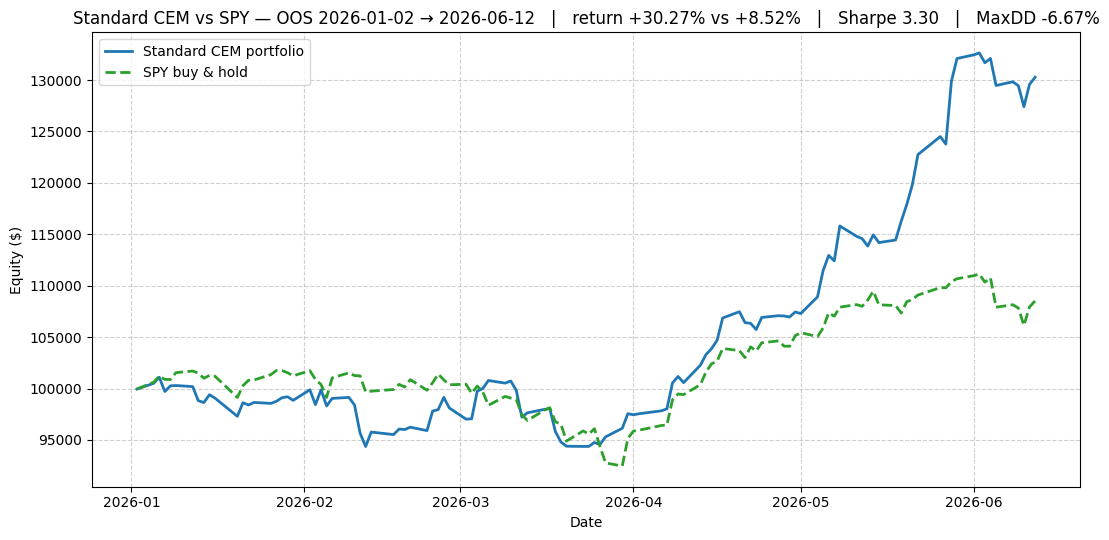

In [7]:
def plot_equity(bench: str, save_path: Path) -> None:
    eq = equity_logs[bench]
    r = summary.loc[summary["benchmark"] == bench].iloc[0]
    dates = pd.to_datetime(eq["date"])
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(dates, eq["equity"], label="Standard CEM portfolio",
            color="#1f77b4", linewidth=2)
    ax.plot(dates, eq["benchmark_equity"], label=f"{bench} buy & hold",
            color="#2ca02c", linestyle="--", linewidth=2)
    ax.set_title(
        f"Standard CEM vs {bench} — OOS {r['oos_start']} → {r['oos_end']}   |   "
        f"return {r['portfolio_return_pct']:+.2f}% vs {r['benchmark_return_pct']:+.2f}%   |   "
        f"Sharpe {r['sharpe']:.2f}   |   MaxDD {r['max_drawdown_pct']:+.2f}%"
    )
    ax.set_ylabel("Equity ($)")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"figure saved → {save_path}")
    plt.show()


plot_equity("SPY", OUT_DIR / "cem_vs_spy_equity.png")

figure saved → C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs\cem_vs_qqq_equity.png


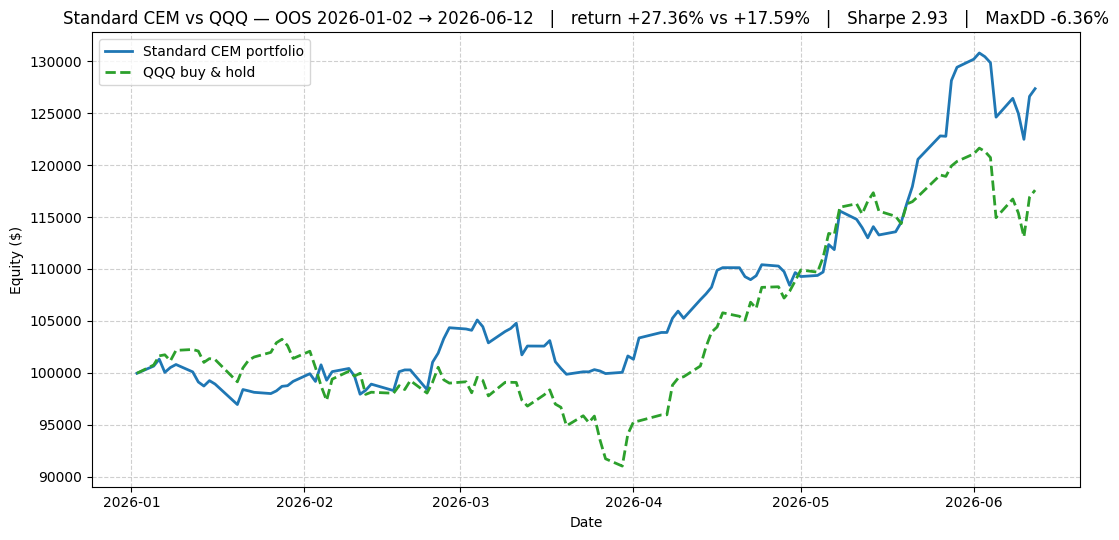

In [8]:
plot_equity("QQQ", OUT_DIR / "cem_vs_qqq_equity.png")

## 5. Output files

All practical outputs are collected in **`notebooks/outputs/`**:

| File | Contents |
|---|---|
| `question_to_assets_mapping.csv` | the complete question → stock/ETF mapping (with relevance and polarity) |
| `spy_trades.csv` / `qqq_trades.csv` | every out-of-sample trade (entry/exit dates, prices, shares, net P&L, exit reason, all four cost legs) |
| `spy_daily_equity.csv` / `qqq_daily_equity.csv` | daily portfolio equity vs benchmark buy-&-hold equity |
| `standard_cem_summary.csv` | portfolio return, benchmark return, excess return, Sharpe, max drawdown, terminal equity, number of trades, transaction costs |
| `cem_fitted_parameters.json` | the fitted (frozen) CEM policy per benchmark |
| `cem_vs_spy_equity.png` / `cem_vs_qqq_equity.png` | the two comparison figures |

The full audit trail (train-window logs, allocation/disposition logs, trade forensics,
the complete CEM fitness population) lives in `runs/standard_cem_notebook/`, following
the project's `runs/<run-id>/` output convention.

In [9]:
copies = {
    "spy_trades.csv":        RUN_DIR / "experiment_trade_logs_clean" / "spy_baseline_test.csv",
    "qqq_trades.csv":        RUN_DIR / "experiment_trade_logs_clean" / "qqq_baseline_test.csv",
    "spy_daily_equity.csv":  RUN_DIR / "experiment_equity_logs_clean" / "spy_baseline_test.csv",
    "qqq_daily_equity.csv":  RUN_DIR / "experiment_equity_logs_clean" / "qqq_baseline_test.csv",
}
for name, src in copies.items():
    shutil.copyfile(src, OUT_DIR / name)

print(f"Practical outputs in {OUT_DIR}:\n")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:38s} {p.stat().st_size:>10,} bytes")

Practical outputs in C:\Users\Liran\AppData\Local\Temp\claude\C--Users-Liran-PycharmProjects-cem-clean-repo\81d3a5f4-1ae2-4acd-831e-021d4a21775f\scratchpad\polymarket_strategy\notebooks\outputs:

  cem_fitted_parameters.json                    740 bytes
  cem_vs_qqq_equity.png                     124,993 bytes
  cem_vs_spy_equity.png                     114,260 bytes
  qqq_daily_equity.csv                        5,248 bytes
  qqq_trades.csv                             86,367 bytes
  question_to_assets_mapping.csv             63,916 bytes
  spy_daily_equity.csv                        5,148 bytes
  spy_trades.csv                             84,037 bytes
  standard_cem_summary.csv                      420 bytes


## 6. Verification

The standard CEM experiment is deterministic for a given seed. The cell below checks
this run against the project's canonical seed-42 standard-CEM results (the `Baseline`
rows of `runs/icaif_base_vs_all_seed42`, i.e. the numbers behind the paper's
seed-42 matrix), and that every promised output file exists.

In [10]:
CANONICAL = {
    "SPY": {"portfolio_return_pct": 30.2742, "benchmark_return_pct": 8.5199,
            "excess_return_pct": 21.7543, "sharpe": 3.2975,
            "max_drawdown_pct": -6.6651, "n_trades": 225},
    "QQQ": {"portfolio_return_pct": 27.3641, "benchmark_return_pct": 17.5912,
            "excess_return_pct": 9.7729, "sharpe": 2.9321,
            "max_drawdown_pct": -6.3585, "n_trades": 223},
}

required_outputs = [
    "question_to_assets_mapping.csv",
    "spy_trades.csv", "qqq_trades.csv",
    "spy_daily_equity.csv", "qqq_daily_equity.csv",
    "standard_cem_summary.csv", "cem_fitted_parameters.json",
    "cem_vs_spy_equity.png", "cem_vs_qqq_equity.png",
]
missing = [n for n in required_outputs if not (OUT_DIR / n).exists()]
assert not missing, f"missing output files: {missing}"
assert set(results["experiment"]) == {"Baseline"}
assert set(results["benchmark"]) == {"SPY", "QQQ"}
assert len(mapping) == mapping[["question", "symbol"]].drop_duplicates().shape[0]
assert pd.read_csv(OUT_DIR / "question_to_assets_mapping.csv").shape[0] == len(mapping)

report, all_match = [], True
for bench, ref in CANONICAL.items():
    row = summary.loc[summary["benchmark"] == bench].iloc[0]
    for metric, expected in ref.items():
        got = float(row[metric])
        tol = 0.5 if metric == "n_trades" else 1e-3
        ok = abs(got - float(expected)) <= tol
        all_match &= ok
        report.append({"benchmark": bench, "metric": metric,
                       "this_run": got, "canonical_run": expected, "match": ok})
display(pd.DataFrame(report))

print(f"output files                 : all {len(required_outputs)} present")
print(f"active experiment arms       : {sorted(set(results['experiment']))}")
if all_match:
    print("RESULT MATCH                 : this notebook reproduces the existing "
          "standard CEM experiment exactly.")
else:
    print("RESULT MATCH                 : DIFFERS from the canonical run — likely "
          "library-version drift; inspect the table above.")

,benchmark,metric,this_run,canonical_run,match
0,SPY,portfolio_return_pct,30.2742,30.2742,True
1,SPY,benchmark_return_pct,8.5199,8.5199,True
2,SPY,excess_return_pct,21.7543,21.7543,True
3,SPY,sharpe,3.2975,3.2975,True
4,SPY,max_drawdown_pct,-6.6651,-6.6651,True
5,SPY,n_trades,225.0000,225.0000,True
6,QQQ,portfolio_return_pct,27.3641,27.3641,True
7,QQQ,benchmark_return_pct,17.5912,17.5912,True
8,QQQ,excess_return_pct,9.7729,9.7729,True
9,QQQ,sharpe,2.9321,2.9321,True


output files                 : all 9 present
active experiment arms       : ['Baseline']
RESULT MATCH                 : this notebook reproduces the existing standard CEM experiment exactly.
